Dataset Shape: (506, 14)

Support Vector Regression
----------------------------
MAE  : 2.7317
MSE  : 25.6685
RMSE : 5.0664
R²   : 0.6500

Decision Tree Regression
----------------------------
MAE  : 2.3941
MSE  : 10.4161
RMSE : 3.2274
R²   : 0.8580

Model Comparison:
                    Model      MAE     RMSE  R2 Score
Support Vector Regression 2.731716 5.066413  0.649977
 Decision Tree Regression 2.394118 3.227395  0.857963


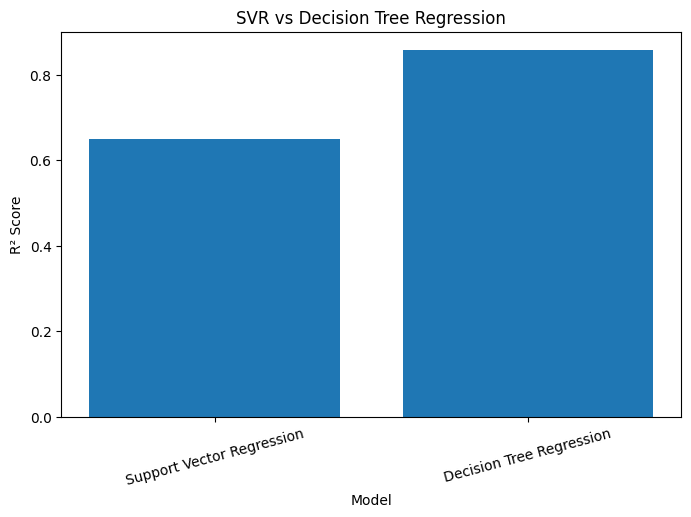


Task 2 Completed Successfully.
Name: Karthik


In [1]:
# Experiment 04 - Task 02
# Support Vector Regression and Decision Tree Regression
# Name: Karthik

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load Boston Housing Dataset
url = "https://raw.githubusercontent.com/selva86/datasets/master/BostonHousing.csv"

df = pd.read_csv(url)

print("Dataset Shape:", df.shape)

# Features and target
X = df.drop("medv", axis=1)
y = df["medv"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Standardization for SVR
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# -----------------------------
# Support Vector Regression
# -----------------------------

svr_model = SVR(
    kernel="rbf"
)

svr_model.fit(
    X_train_scaled,
    y_train
)

svr_predictions = svr_model.predict(
    X_test_scaled
)

svr_mae = mean_absolute_error(
    y_test,
    svr_predictions
)

svr_mse = mean_squared_error(
    y_test,
    svr_predictions
)

svr_rmse = np.sqrt(svr_mse)

svr_r2 = r2_score(
    y_test,
    svr_predictions
)

print("\nSupport Vector Regression")
print("----------------------------")
print(f"MAE  : {svr_mae:.4f}")
print(f"MSE  : {svr_mse:.4f}")
print(f"RMSE : {svr_rmse:.4f}")
print(f"R²   : {svr_r2:.4f}")

# -----------------------------
# Decision Tree Regression
# -----------------------------

dt_model = DecisionTreeRegressor(
    random_state=42
)

dt_model.fit(
    X_train,
    y_train
)

dt_predictions = dt_model.predict(
    X_test
)

dt_mae = mean_absolute_error(
    y_test,
    dt_predictions
)

dt_mse = mean_squared_error(
    y_test,
    dt_predictions
)

dt_rmse = np.sqrt(dt_mse)

dt_r2 = r2_score(
    y_test,
    dt_predictions
)

print("\nDecision Tree Regression")
print("----------------------------")
print(f"MAE  : {dt_mae:.4f}")
print(f"MSE  : {dt_mse:.4f}")
print(f"RMSE : {dt_rmse:.4f}")
print(f"R²   : {dt_r2:.4f}")

# -----------------------------
# Model Comparison
# -----------------------------

comparison = pd.DataFrame({
    "Model": [
        "Support Vector Regression",
        "Decision Tree Regression"
    ],
    "MAE": [
        svr_mae,
        dt_mae
    ],
    "RMSE": [
        svr_rmse,
        dt_rmse
    ],
    "R2 Score": [
        svr_r2,
        dt_r2
    ]
})

print("\nModel Comparison:")
print(comparison.to_string(index=False))

# Comparison graph
plt.figure(figsize=(8, 5))

plt.bar(
    comparison["Model"],
    comparison["R2 Score"]
)

plt.xlabel("Model")
plt.ylabel("R² Score")
plt.title("SVR vs Decision Tree Regression")
plt.xticks(rotation=15)
plt.show()

print("\nTask 2 Completed Successfully.")
print("Name: Karthik")